MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


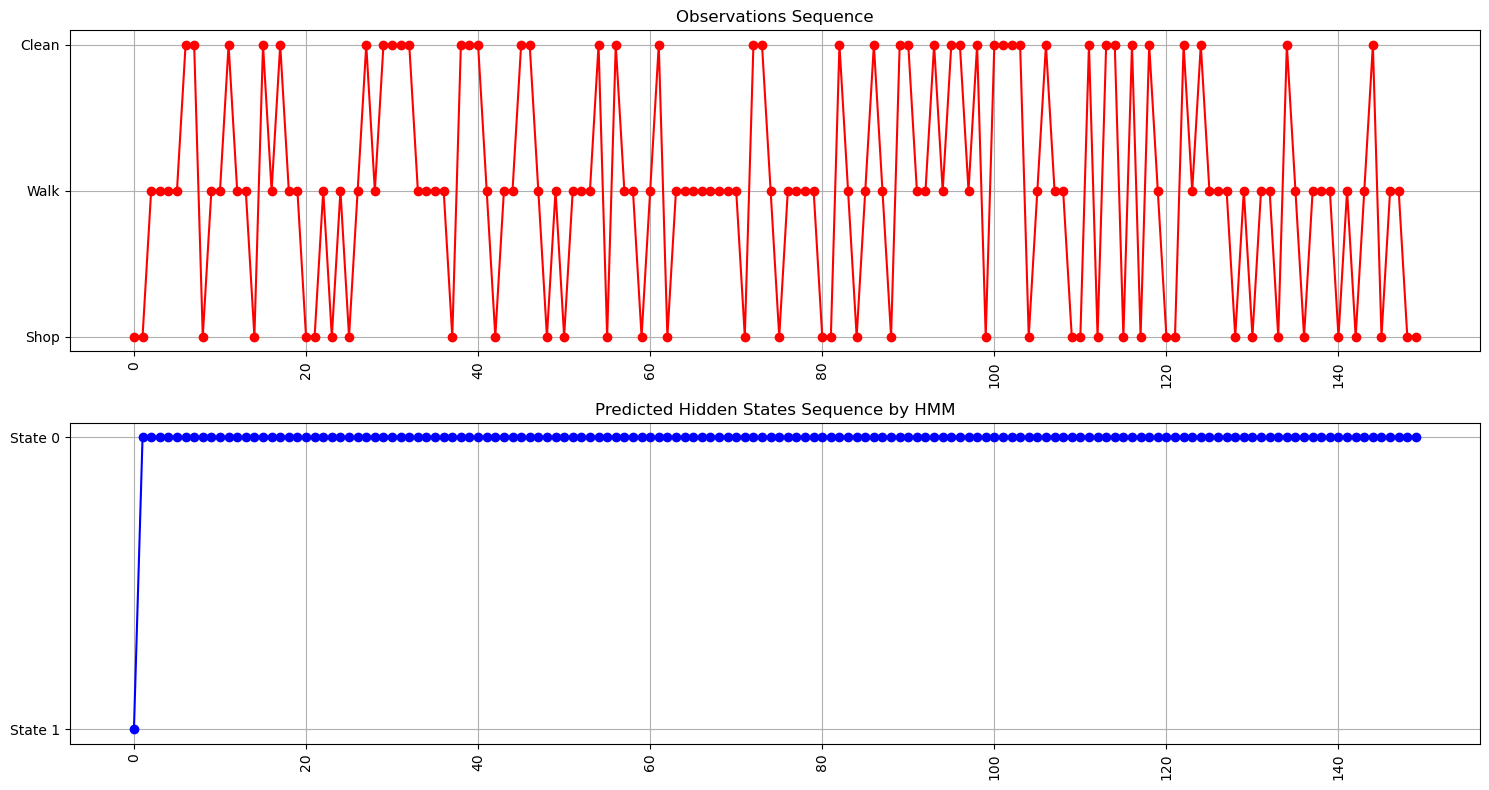

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn import hmm

# Load the dataset
data = pd.read_csv('hmm_sample_dataset.csv')  # Path to your CSV

# Encode observations as integers
observation_mapping = {'Walk': 0, 'Shop': 1, 'Clean': 2}
X = data['Observation'].map(observation_mapping).values.reshape(-1, 1)

# Create and fit HMM
model = hmm.MultinomialHMM(n_components=2, random_state=42, n_iter=100)
model.fit(X)

# Predict hidden states
predicted_states = model.predict(X)

# Map predictions for better labeling
state_labels = {0: 'State 0', 1: 'State 1'}
predicted_state_names = [state_labels[state] for state in predicted_states]

# Plot the results
plt.figure(figsize=(15, 8))

# Observations
plt.subplot(2, 1, 1)
plt.plot(data['Observation'], 'ro-', label='Observations')
plt.title('Observations Sequence')
plt.xticks(rotation=90)
plt.grid(True)

# Predicted hidden states
plt.subplot(2, 1, 2)
plt.plot(predicted_state_names, 'bo-', label='Predicted Hidden States')
plt.title('Predicted Hidden States Sequence by HMM')
plt.xticks(rotation=90)
plt.grid(True)

plt.tight_layout()
plt.show()


In [3]:
!pip install hmmlearn
